In [27]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tensorflow.keras.models import load_model
import tensorflow as tf
import random
import os

In [6]:
# ----------------------------------------------------
# 1. 환경 설정 및 경로 정의 (PV 맞춤형)
# ----------------------------------------------------
N_ENSEMBLE = 10
TARGET_NAMES = ["Deflection(mm)", "Weight(kg)"]
MODEL_PATHS = [f'saved_models/pv_ensemble_model_{i+1}.keras' for i in range(N_ENSEMBLE)]
SCALER_DIR = '.' 

# ★ 수정: PSO가 아닌 BO 5% 민감도 결과 사용
BO_RESULT_PATH = 'robustness_analysis_BO_PV/robustness_results_5pct_pv.csv' 
PARETO_OUTPUT_DIR = 'bo_pareto_results_pv'
os.makedirs(PARETO_OUTPUT_DIR, exist_ok=True)

# ----------------------------------------------------
# 2. 모델 및 스케일러 로딩
# ----------------------------------------------------
try:
    ENSEMBLE_MODELS = [load_model(path, compile=False) for path in MODEL_PATHS]
    X_SCALER_LOADED = joblib.load(os.path.join(SCALER_DIR, 'scaler_X_pvmodule.joblib'))
    # PV 모델은 이미 원본 값을 출력하므로 Y 스케일러는 inverse_transform에 사용하지 않음
    print("✅ PV 앙상블 모델 및 X 스케일러 로딩 완료.")
except Exception as e:
    print(f"❌ 로딩 실패: {e}")
    raise

✅ PV 앙상블 모델 및 X 스케일러 로딩 완료.


C:\Users\admin\anaconda3\envs\py31010_auto\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


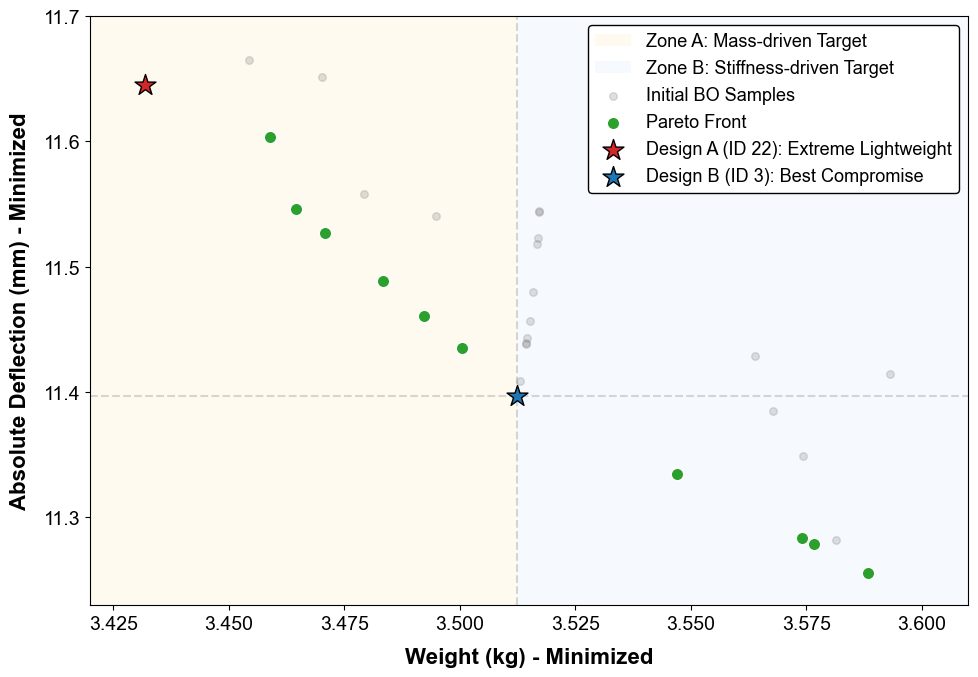

✅ 시각화 완료: 'bo_pareto_results_pv\PV_Pareto_2_Zones_Paper_Ready_f.png'


In [21]:
# ----------------------------------------------------
# 1. 하이라이트 할 두 개의 최적해 선정 (Run -> ID 명칭 변경)
# ----------------------------------------------------
RUN_LIGHTWEIGHT = 22  
RUN_KNEE_POINT = 3    

run_A = df_total[df_total['Run'] == RUN_LIGHTWEIGHT]
run_B = df_total[df_total['Run'] == RUN_KNEE_POINT]
df_pareto_others = df_pareto_raw[~df_pareto_raw['Run'].isin([RUN_LIGHTWEIGHT, RUN_KNEE_POINT])]

# ----------------------------------------------------
# 2. 미니멀리즘 논문용 시각화 (번잡함 제거, Arial 폰트 세팅)
# ----------------------------------------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14 # 전체 기본 글꼴 크기 통일

fig, ax = plt.subplots(figsize=(10, 7)) # 비율을 조금 더 타이트하게 조정

# Zone 분할 (ID 3 기준)
split_weight = run_B['Weight(kg)'].values[0] 

# 색상을 논문에 더 어울리게 한 톤 더 차분하게 조정
ax.axvspan(3.42, split_weight, facecolor='#FFF8E7', alpha=0.6, label='Zone A: Mass-driven Target')
ax.axvspan(split_weight, 3.61, facecolor='#F0F8FF', alpha=0.6, label='Zone B: Stiffness-driven Target')

# 점선 기준선 (투명도를 높여 방해되지 않게)
ax.axvline(x=split_weight, color='gray', linestyle='--', alpha=0.3)
ax.axhline(y=run_B['Abs_Deflection'].values[0], color='gray', linestyle='--', alpha=0.3)

# 산점도 데이터 표시
df_others = df_total[~df_total['Run'].isin(df_pareto_raw['Run'])]
ax.scatter(df_others[T_COLS[0]], df_others[T_COLS[1]], 
           color='gray', alpha=0.25, label='Initial BO Samples', s=30, zorder=3)

ax.scatter(df_pareto_others[T_COLS[0]], df_pareto_others[T_COLS[1]], 
           color='#2ca02c', label='Pareto Front', s=80, edgecolors='white', zorder=4)

# 최적해 하이라이트
ax.scatter(run_A[T_COLS[0]], run_A[T_COLS[1]], 
           color='#d62728', label='Design A (ID 22): Extreme Lightweight', 
           s=250, marker='*', edgecolors='black', zorder=5)

ax.scatter(run_B[T_COLS[0]], run_B[T_COLS[1]], 
           color='#1f77b4', label='Design B (ID 3): Best Compromise', 
           s=250, marker='*', edgecolors='black', zorder=5)

# 축 설정 및 제목(Title) 제거
ax.set_xlim([3.42, 3.61])
ax.set_ylim([11.23, 11.7])
ax.set_xlabel("Weight (kg) - Minimized", labelpad=10, fontweight='bold', fontsize=16)
ax.set_ylabel("Absolute Deflection (mm) - Minimized", labelpad=10, fontweight='bold', fontsize=16)
ax.grid(False)

# 범례 깔끔하게 정리 (그래프 영역을 가리지 않도록 위치 조정)
ax.legend(loc='upper right', framealpha=1.0, edgecolor='black', fontsize=13)

plt.tight_layout()
save_path = os.path.join(PARETO_OUTPUT_DIR, "PV_Pareto_2_Zones_Paper_Ready_f.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ 시각화 완료: '{save_path}'")

In [23]:
# ----------------------------------------------------
# 💡 선택된 최적해 (ID 22, ID 3) 상세 수치 확인 코드
# ----------------------------------------------------
TARGET_IDS = [22, 3] # 확인하고 싶은 Run ID (22번: 경량화, 3번: 밸런스)

print("\n" + "="*65)
print(" 🏆 시나리오별 최종 선택 최적해 상세 데이터 (논문 Table 작성용)")
print("="*65)

for run_id in TARGET_IDS:
    # 해당 ID의 행(row) 데이터 추출
    target_data = df_total[df_total['Run'] == run_id].iloc[0]
    
    print(f"\n▶ [ Design ID: {run_id} ]")
    if run_id == 22:
        print("  - 설계 시나리오: Zone A (극한의 경량화 및 재료비 절감 최우선)")
    elif run_id == 3:
        print("  - 설계 시나리오: Zone B (Knee Point, 강성과 경량화의 최적 타협해)")
        
    print("  [ 최적 단면 설계 변수 (Design Factors) ]")
    print(f"    a = {target_data['a']:.4f}")
    print(f"    b = {target_data['b']:.4f}")
    print(f"    c = {target_data['c']:.4f}")
    print(f"    d = {target_data['d']:.4f}")
    print(f"    e = {target_data['e']:.4f}")
    
    print("  [ 딥 앙상블 예측 성능 (Predicted Targets) ]")
    print(f"    처짐량 (Deflection) : {target_data['Abs_Deflection']:.4f} mm (안전 한계선: 12.3 mm)")
    print(f"    단면 무게 (Weight)  : {target_data['Weight(kg)']:.4f} kg (안전 한계선: 3.6 kg)")
    print("-" * 65)


 🏆 시나리오별 최종 선택 최적해 상세 데이터 (논문 Table 작성용)

▶ [ Design ID: 22 ]
  - 설계 시나리오: Zone A (극한의 경량화 및 재료비 절감 최우선)
  [ 최적 단면 설계 변수 (Design Factors) ]
    a = 1.5000
    b = 14.0000
    c = 1.5000
    d = 2.4204
    e = 2.5000
  [ 딥 앙상블 예측 성능 (Predicted Targets) ]
    처짐량 (Deflection) : 11.6451 mm (안전 한계선: 12.3 mm)
    단면 무게 (Weight)  : 3.4319 kg (안전 한계선: 3.6 kg)
-----------------------------------------------------------------

▶ [ Design ID: 3 ]
  - 설계 시나리오: Zone B (Knee Point, 강성과 경량화의 최적 타협해)
  [ 최적 단면 설계 변수 (Design Factors) ]
    a = 1.5000
    b = 14.0000
    c = 1.5000
    d = 3.0000
    e = 2.5000
  [ 딥 앙상블 예측 성능 (Predicted Targets) ]
    처짐량 (Deflection) : 11.3970 mm (안전 한계선: 12.3 mm)
    단면 무게 (Weight)  : 3.5125 kg (안전 한계선: 3.6 kg)
-----------------------------------------------------------------


In [28]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 분석할 두 최적해의 입력 변수 (a, b, c, d, e)
# 주의: ID 22의 d는 FEA 검증과 동일하게 2.4로 맞춤
TARGET_DESIGNS = {
    "Design A (ID 22)": [1.5000, 14.0000, 1.5000, 2.4000, 2.5000],
    "Design B (ID 3)":  [1.5000, 14.0000, 1.5000, 3.0000, 2.5000]
}
TARGET_NAMES = ["Deflection(mm)", "Weight(kg)"]

table_9_data = []

print("\n" + "="*80)
print(" 📊 Table 9. Predictive Reliability Analysis (95% PI) for Selected Designs")
print("="*80)

for design_name, x_values in TARGET_DESIGNS.items():
    # 입력값 스케일링
    X_input = np.array([x_values])
    X_scaled = X_SCALER_LOADED.transform(X_input)
    
    # 10개 앙상블 모델 예측 수행 (원본 물리적 값 반환)
    preds_raw = [model.predict(X_scaled, verbose=0)[0] for model in ENSEMBLE_MODELS]
    preds_arr = np.array(preds_raw)
    
    # 기초 통계량 계산
    mean_vals = np.mean(preds_arr, axis=0)
    std_vals = np.std(preds_arr, axis=0)
    
    for i, target in enumerate(TARGET_NAMES):
        mean = mean_vals[i]
        std = std_vals[i]
        cv = (std / abs(mean)) * 100
        
        # 95% 예측 구간 (Prediction Interval)
        lower_pi = mean - 1.96 * std
        upper_pi = mean + 1.96 * std
        pi_str = f"[{lower_pi:.4f}, {upper_pi:.4f}]"
        
        table_9_data.append({
            "Design ID": design_name if i == 0 else "", # 표 병합 시각화 효과
            "Target": target,
            "Mean (μ)": f"{mean:.4f}",
            "Std (σ)": f"{std:.4f}",
            "CV (%)": f"{cv:.2f}",
            "95% PI": pi_str
        })

df_table_9 = pd.DataFrame(table_9_data)
print(df_table_9.to_markdown(index=False, stralign="center"))
print("="*80)


 📊 Table 9. Predictive Reliability Analysis (95% PI) for Selected Designs
|    Design ID     |     Target     |   Mean (μ) |   Std (σ) |   CV (%) |        95% PI        |
|:----------------:|:--------------:|-----------:|----------:|---------:|:--------------------:|
| Design A (ID 22) | Deflection(mm) |   -11.6524 |    0.064  |     0.55 | [-11.7780, -11.5269] |
|                  |   Weight(kg)   |     3.4295 |    0.0373 |     1.09 |   [3.3564, 3.5025]   |
| Design B (ID 3)  | Deflection(mm) |   -11.397  |    0.0661 |     0.58 | [-11.5265, -11.2675] |
|                  |   Weight(kg)   |     3.5125 |    0.0409 |     1.16 |   [3.4323, 3.5926]   |
